# NHL Salary Prediction: Моделирование

## Baseline и эксперименты с моделями

## Важно: Все эксперименты тут актуальны на момент CP1. В CP2 были получены чуть лучшие результаты для дефолтных моделей засчет добавления новых признаков, а также там есть тюнинг, Stacking и другие эксперименты. Выбор лучше модели итоговой там же. Всё что было выполнено в рамках CP2 описано уже в 3 ноутбуке.

Все модели обучаются на `data/features/*_train.csv`, оцениваются на `val`.
Test-сет не используется до финального выбора модели (это будет в cp2).

Таргет: `log_cap_hit` (логарифм зарплаты). Метрики считаются в исходном
пространстве через `expm1` т.е. в долларах USD.

In [2]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import logging
logging.getLogger().setLevel(logging.WARNING)

sys.path.append("..")
from src.modeling import (
    load_splits, get_feature_cols, run_baseline, run_models,
    run_dim_reduction, load_model, evaluate
)

plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 11

root = Path("..")
target_col = "log_cap_hit"

train_sk, val_sk, test_sk = load_splits("skaters")
feature_cols_sk = get_feature_cols(train_sk)

x_train_sk = train_sk[feature_cols_sk]
y_train_sk = train_sk[target_col]
x_val_sk = val_sk[feature_cols_sk]
y_val_sk = val_sk[target_col]

print(f"Скейтеры, признаков: {len(feature_cols_sk)}")
print(f"Train: {len(train_sk)}, Val: {len(val_sk)}, Test: {len(test_sk)}")

Скейтеры, признаков: 77
Train: 1829, Val: 601, Test: 476


## 1. Признаки

Из 90 исходных колонок скейтеров после удаления id-колонок, таргета
и мультиколлинеарных дублей (выявленных в EDA) остаётся 77 признаков.

In [3]:
print("Все признаки модели скейтеров:")
for i, col in enumerate(feature_cols_sk, 1):
    print(f" {i:2d}. {col}")

Все признаки модели скейтеров:
  1. assists
  2. evGoals
  3. faceoffWinPct
  4. gameWinningGoals
  5. goals
  6. otGoals
  7. penaltyMinutes
  8. plusMinus
  9. points
 10. pointsPerGame
 11. ppGoals
 12. ppPoints
 13. shGoals
 14. shPoints
 15. shootingPct
 16. shots
 17. timeOnIcePerGame
 18. blockedShots
 19. blockedShotsPer60
 20. emptyNetAssists
 21. emptyNetGoals
 22. emptyNetPoints
 23. firstGoals
 24. giveaways
 25. giveawaysPer60
 26. hits
 27. hitsPer60
 28. missedShotCrossbar
 29. missedShotGoalpost
 30. missedShotOverNet
 31. missedShots
 32. takeaways
 33. takeawaysPer60
 34. defensiveZoneFaceoffPct
 35. defensiveZoneFaceoffs
 36. evFaceoffPct
 37. evFaceoffs
 38. neutralZoneFaceoffPct
 39. neutralZoneFaceoffs
 40. offensiveZoneFaceoffPct
 41. offensiveZoneFaceoffs
 42. ppFaceoffPct
 43. ppFaceoffs
 44. shFaceoffPct
 45. shFaceoffs
 46. totalFaceoffs
 47. ppAssists
 48. ppGoalsForPer60
 49. ppGoalsPer60
 50. ppIndividualSatForPer60
 51. ppPointsPer60
 52. ppPrimaryAssists

## 2. Baseline: LinearRegression

Простая линейная регрессия без дополнительной обработки признаков.
Служит нижней границей качества: все последующие модели должны её превзойти.

In [4]:
results_sk = []
baseline_sk = run_baseline(x_train_sk, y_train_sk, x_val_sk, y_val_sk,
                            results_sk, prefix="skaters")
metrics = results_sk[0]
print(f"MAE: {metrics['mae']/1e6:.3f}M")
print(f"RMSE: {metrics['rmse']/1e6:.3f}M")
print(f"R²: {metrics['r2']:.3f}")
print(f"MAPE: {metrics['mape']:.1f}%")

MAE: 1.307M
RMSE: 1.869M
R²: 0.581
MAPE: 46.0%


### Результат baseline

Модель объясняет 58% дисперсии зарплат. MAE 1.3M означает что в среднем
модель ошибается на 1.3 миллиона долларов, при медианной зарплате ~3M
это ~43% ошибки. MAPE 46% подтверждает это.

Высокая ошибка ожидаема: линейная регрессия не улавливает нелинейные
зависимости и страдает от мультиколлинеарности признаков.

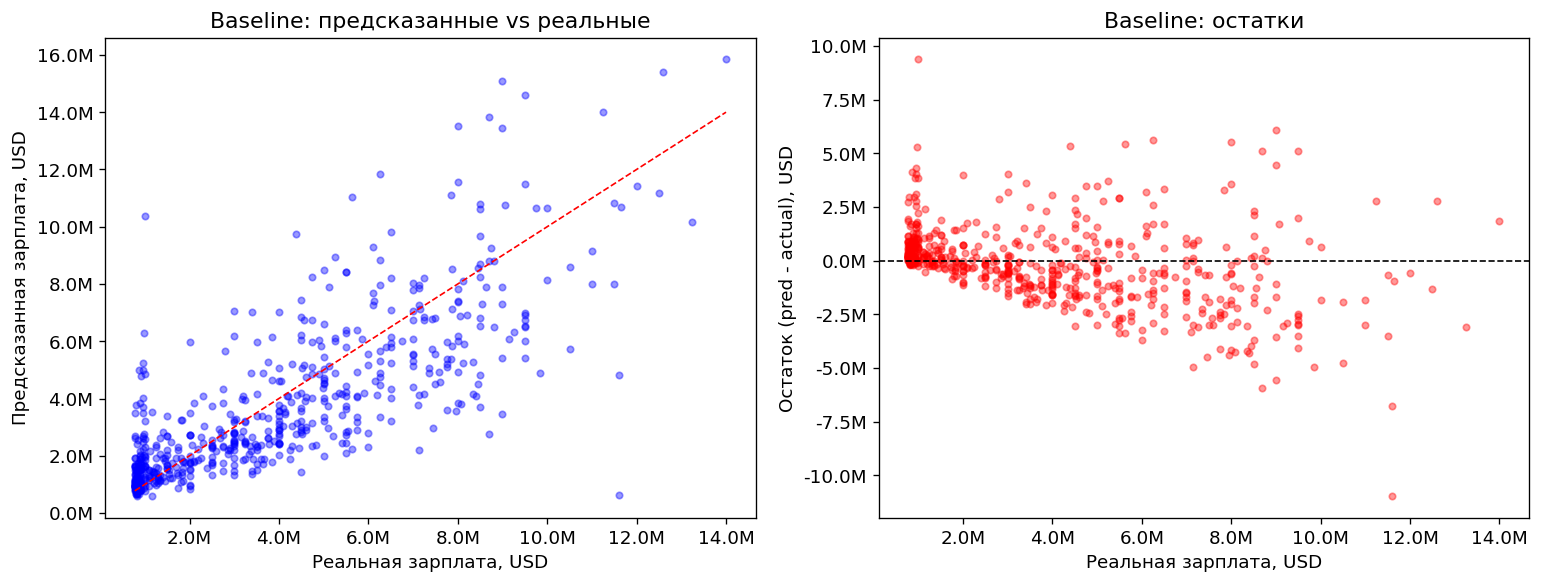

In [5]:
pred_log = baseline_sk.predict(x_val_sk)
pred = np.expm1(pred_log)
actual = np.expm1(y_val_sk.values)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(actual, pred, alpha=0.4, s=15, color="blue")
axes[0].plot([actual.min(), actual.max()],
             [actual.min(), actual.max()],
             color="red", linewidth=1, linestyle="--")
axes[0].set_xlabel("Реальная зарплата, USD")
axes[0].set_ylabel("Предсказанная зарплата, USD")
axes[0].set_title("Baseline: предсказанные vs реальные")
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))

residuals = pred - actual
axes[1].scatter(actual, residuals, alpha=0.4, s=15, color="red")
axes[1].axhline(0, color="black", linewidth=1, linestyle="--")
axes[1].set_xlabel("Реальная зарплата, USD")
axes[1].set_ylabel("Остаток (pred - actual), USD")
axes[1].set_title("Baseline: остатки")
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))

plt.tight_layout()
plt.savefig(root / "report/images/baseline_scatter.png", bbox_inches="tight")
plt.show()

### Анализ графиков baseline

**Predicted vs Actual:** точки в целом следуют диагонали, но с большим разбросом.
Заметна систематическая проблема: модель завышает низкие зарплаты и занижает топ-контракты.
Это типичная проблема линейной регрессии, она тянется к среднему.

**График остатков**: остатки не случайны, есть чёткий тренд: 
при низких зарплатах остаток положительный (переоценка), при высоких отрицательный
(недооценка). Это говорит о том что линейная модель не улавливает нелинейность
зависимости. 

## 3. Основные модели

In [6]:
trained_sk = run_models(x_train_sk, y_train_sk, x_val_sk, y_val_sk,
                         results_sk, prefix="skaters")

results_df = pd.DataFrame(results_sk)
print(results_df[["label", "mae", "rmse", "r2", "mape"]].to_string(index=False))

                  label          mae         rmse       r2      mape
skaters_baseline_linear 1.306946e+06 1.869500e+06 0.581378 46.049954
          skaters_ridge 1.306623e+06 1.860769e+06 0.585278 45.050050
  skaters_random_forest 1.229105e+06 1.767554e+06 0.625789 36.066532
        skaters_xgboost 1.166761e+06 1.666146e+06 0.667495 35.684961
       skaters_lightgbm 1.094745e+06 1.602110e+06 0.692563 34.289998


In [7]:
def format_results(results: list[dict]) -> pd.DataFrame:
    df = pd.DataFrame(results).copy()
    df["label"] = df["label"].str.replace("skaters_", "").str.replace("goalies_", "")
    df["MAE"] = df["mae"].apply(lambda x: f"{x/1e6:.3f}M")
    df["RMSE"] = df["rmse"].apply(lambda x: f"{x/1e6:.3f}M")
    df["R²"] = df["r2"].round(3)
    df["MAPE"] = df["mape"].round(1).astype(str) + "%"
    return df[["label", "MAE", "RMSE", "R²", "MAPE"]]

print(format_results(results_sk).to_string(index=False))

          label    MAE   RMSE    R²  MAPE
baseline_linear 1.307M 1.869M 0.581 46.0%
          ridge 1.307M 1.861M 0.585 45.1%
  random_forest 1.229M 1.768M 0.626 36.1%
        xgboost 1.167M 1.666M 0.667 35.7%
       lightgbm 1.095M 1.602M 0.693 34.3%


### Результаты основных моделей (скейтеры, на val)

Каждая следующая модель улучшает baseline. Нелинейные модели (RF, XGBoost, LightGBM)
значительно лучше линейных, что подтверждает гипотезу
из EDA о нелинейности зависимостей. LightGBM лучший по всем метрикам.

Ridge почти не отличается от LinearRegression, регуляризация помогает мало,
потому что мультиколлинеарность уже частично устранена удалением дублей в preprocessing.

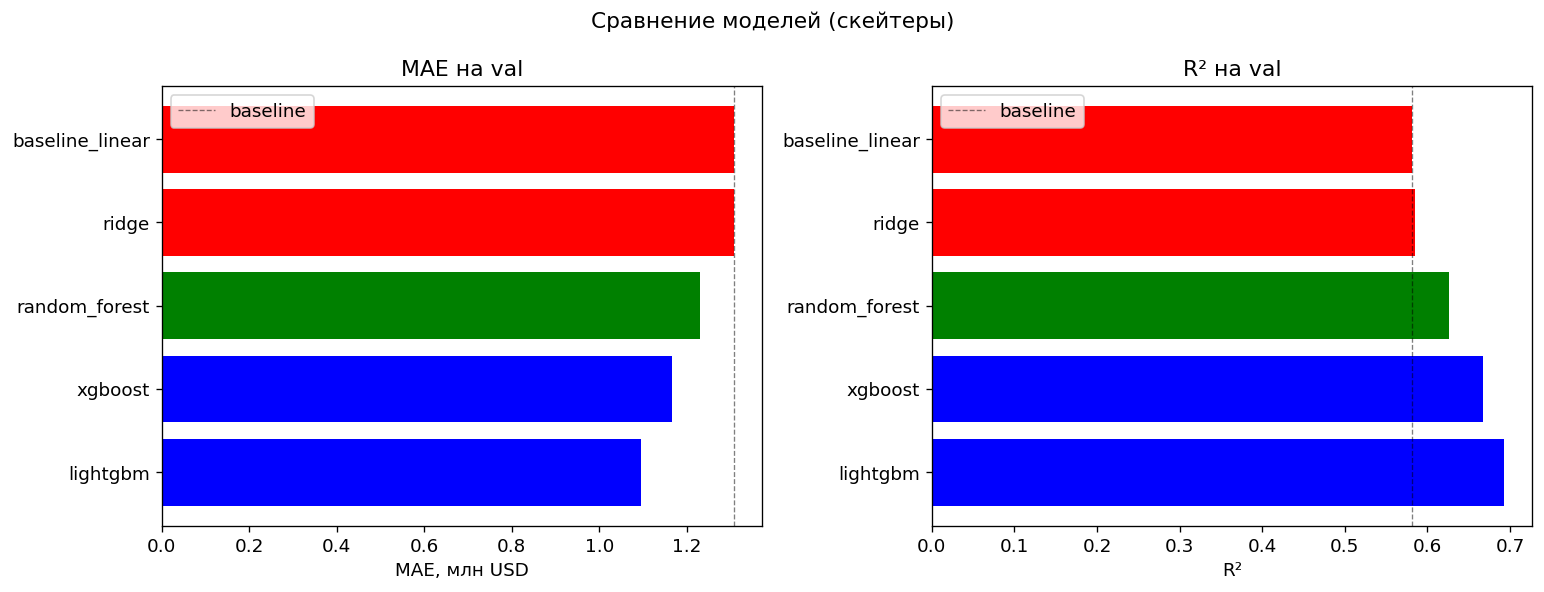

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

labels = [r["label"].replace("skaters_", "") for r in results_sk[:5]]
maes = [r["mae"] / 1e6 for r in results_sk[:5]]
r2s = [r["r2"] for r in results_sk[:5]]
colors = ["red", "red", "green", "blue", "blue"]

axes[0].barh(labels[::-1], maes[::-1], color=colors[::-1])
axes[0].set_xlabel("MAE, млн USD")
axes[0].set_title("MAE на val")
axes[0].axvline(maes[0], color="black", linewidth=0.8,
                linestyle="--", alpha=0.5, label="baseline")
axes[0].legend()

axes[1].barh(labels[::-1], r2s[::-1], color=colors[::-1])
axes[1].set_xlabel("R²")
axes[1].set_title("R² на val")
axes[1].axvline(r2s[0], color="black", linewidth=0.8,
                linestyle="--", alpha=0.5, label="baseline")
axes[1].legend()

plt.suptitle("Сравнение моделей (скейтеры)", fontsize=13)
plt.tight_layout()
plt.savefig(root / "report/images/models_comparison.png", bbox_inches="tight")
plt.show()

### Визуализация сравнения моделей

График подтверждает: линейные модели (красные) хуже нелинейных.
Random Forest (зелёный) - промежуточный результат.
XGBoost и LightGBM (синие) явно лучше baseline по обеим метрикам.

## 4. Уменьшение размерности

In [10]:
selector_sk, pca_sk = run_dim_reduction(
    x_train_sk, y_train_sk, x_val_sk, y_val_sk,
    results_sk, prefix="skaters"
)

print(format_results(results_sk).to_string(index=False))

             label    MAE   RMSE    R²  MAPE
   baseline_linear 1.307M 1.869M 0.581 46.0%
             ridge 1.307M 1.861M 0.585 45.1%
     random_forest 1.229M 1.768M 0.626 36.1%
           xgboost 1.167M 1.666M 0.667 35.7%
          lightgbm 1.095M 1.602M 0.693 34.3%
lgbm_select_39feat 1.101M 1.617M 0.687 33.9%
  pca_37comp_ridge 1.432M 2.016M 0.513 45.6%


### Результаты уменьшения размерности

**SelectFromModel:**
MAE 1.101M vs 1.095M у полного LightGBM т.е. разница всего 0.006M.
При вдвое меньшем количестве признаков модель теряет минимум качества.
Половина признаков избыточна.

**PCA + Ridge:**
MAE 1.432M т.е. хуже baseline. PCA разрушает интерпретируемость признаков. Для табличных данных с содержательными
признаками PCA обычно проигрывает прямому отбору.

**Вывод:** SelectFromModel это разумный компромисс между качеством и простотой модели.
Полный LightGBM остаётся лучшим, но SelectFromModel-версия предпочтительна
если важна скорость инференса.

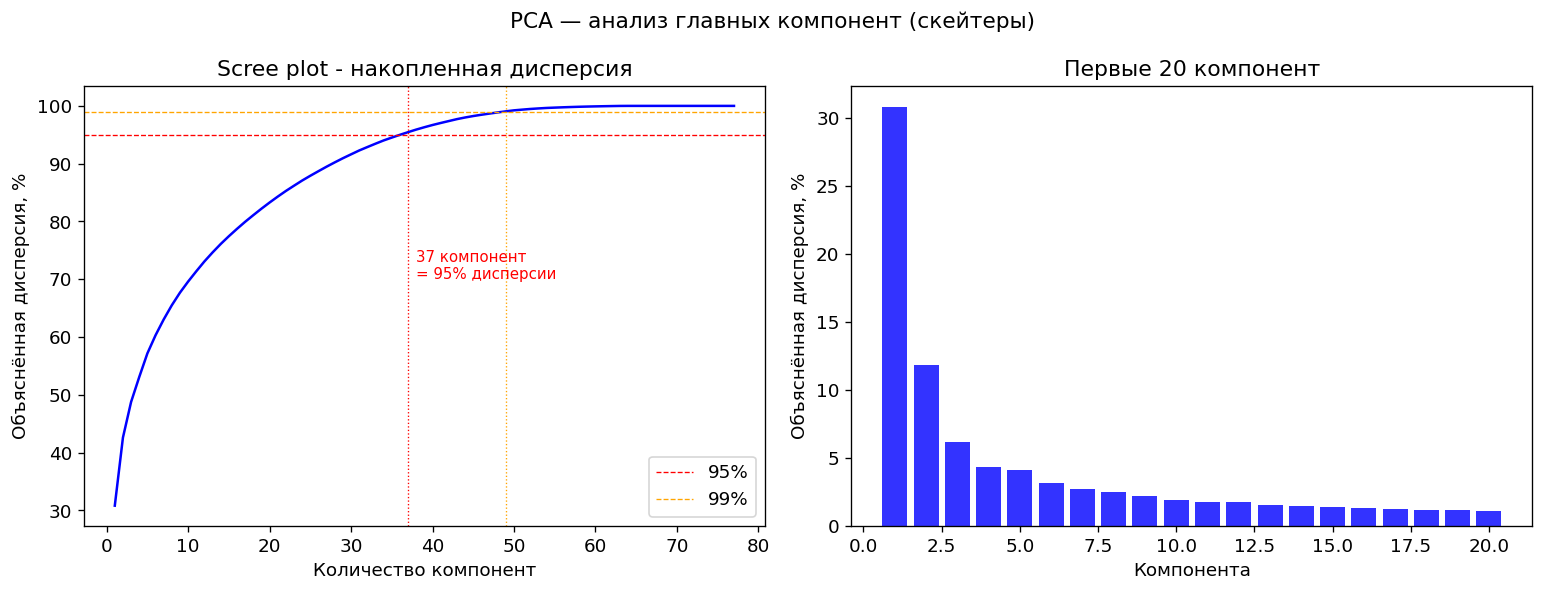

Компонент для 95% дисперсии: 37
Компонент для 99% дисперсии: 49
Всего признаков: 77


In [11]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler = StandardScaler()
x_scaled = scaler.fit_transform(x_train_sk)

pca_full = PCA(random_state=42)
pca_full.fit(x_scaled)

cumvar = np.cumsum(pca_full.explained_variance_ratio_) * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(range(1, len(cumvar) + 1), cumvar, color="blue", linewidth=1.5)
axes[0].axhline(95, color="red", linestyle="--", linewidth=0.8, label="95%")
axes[0].axhline(99, color="orange", linestyle="--", linewidth=0.8, label="99%")
axes[0].axvline(37, color="red", linestyle=":", linewidth=0.8)
n_99 = np.argmax(cumvar >= 99) + 1
axes[0].axvline(n_99, color="orange", linestyle=":", linewidth=0.8)
axes[0].set_xlabel("Количество компонент")
axes[0].set_ylabel("Объяснённая дисперсия, %")
axes[0].set_title("Scree plot - накопленная дисперсия")
axes[0].legend()
axes[0].text(38, 70, f"37 компонент\n= 95% дисперсии", fontsize=9, color="red")

axes[1].bar(range(1, 21),
            pca_full.explained_variance_ratio_[:20] * 100,
            color="blue", alpha=0.8)
axes[1].set_xlabel("Компонента")
axes[1].set_ylabel("Объяснённая дисперсия, %")
axes[1].set_title("Первые 20 компонент")

plt.suptitle("PCA — анализ главных компонент (скейтеры)", fontsize=13)
plt.tight_layout()
plt.savefig(root / "report/images/pca_scree_plot.png", bbox_inches="tight")
plt.show()

print(f"Компонент для 95% дисперсии: 37")
print(f"Компонент для 99% дисперсии: {n_99}")
print(f"Всего признаков: {x_train_sk.shape[1]}")

### Scree plot - анализ PCA

Первая компонента объясняет чуть больше 30% дисперсии.
Вторая компонента примерно 12%.
После 10-й компоненты каждая добавляет менее 2%.

Для 95% дисперсии нужно 37 компонент из 77 т.е. сжатие в 2 раза.
Для 99% - 49 компонент.

Несмотря на компактность PCA-представления, качество модели падает:
Ridge на 37 компонентах хуже baseline.

## 5. Сводная таблица всех экспериментов

                label     MAE    RMSE     R²   MAPE
1            lightgbm  1.095M  1.602M  0.693  34.3%
2  lgbm_select_39feat  1.101M  1.617M  0.687  33.9%
3             xgboost  1.167M  1.666M  0.667  35.7%
4       random_forest  1.229M  1.768M  0.626  36.1%
5               ridge  1.307M  1.861M  0.585  45.1%
6     baseline_linear  1.307M  1.869M  0.581  46.0%
7    pca_37comp_ridge  1.432M  2.016M  0.513  45.6%


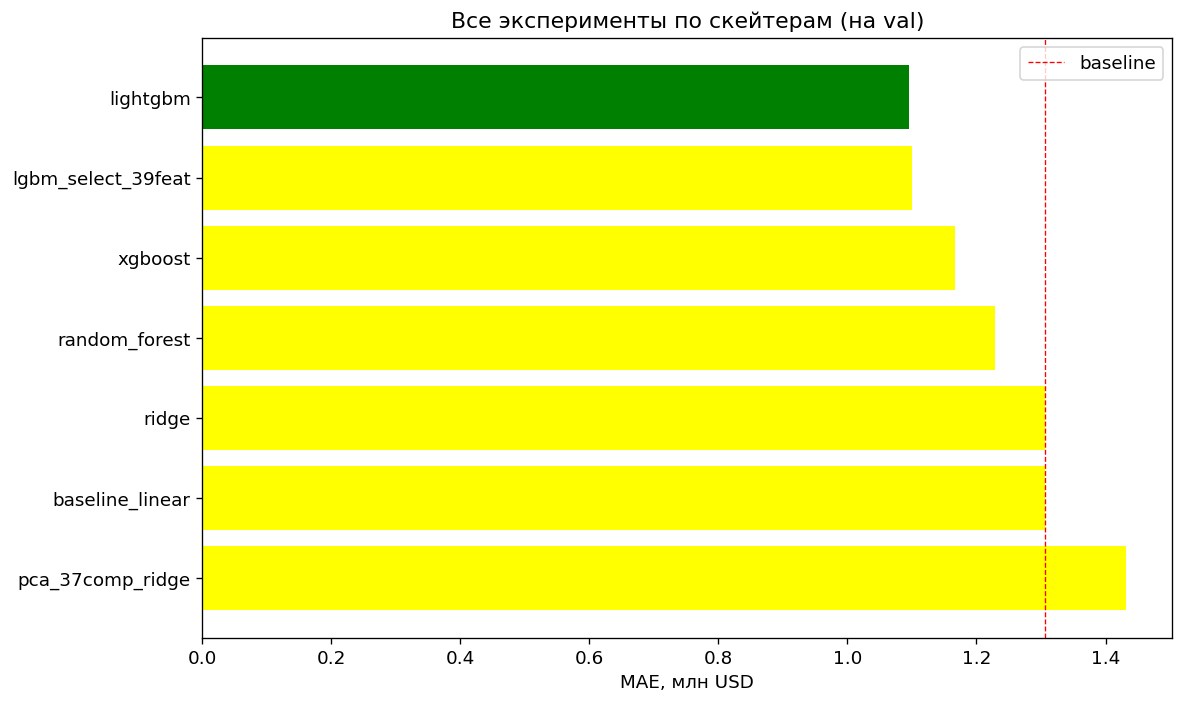

In [13]:
summary = format_results(results_sk).copy()
summary["sort_key"] = [r["mae"] for r in results_sk]
summary = summary.sort_values("sort_key").drop(columns="sort_key").reset_index(drop=True)
summary.index += 1
print(summary.to_string())

fig, ax = plt.subplots(figsize=(10, 6))
labels_all = summary["label"].tolist()
maes_all = [r["mae"] / 1e6 for r in sorted(results_sk, key=lambda x: x["mae"])]
colors_all = ["green" if m == min(maes_all) else "yellow" for m in maes_all]

ax.barh(labels_all[::-1], maes_all[::-1], color=colors_all[::-1])
ax.axvline(results_sk[0]["mae"] / 1e6, color="red", linewidth=0.8,
           linestyle="--", label="baseline")
ax.set_xlabel("MAE, млн USD")
ax.set_title("Все эксперименты по скейтерам (на val)")
ax.legend()

plt.tight_layout()
plt.savefig(root / "report/images/all_experiments.png", bbox_inches="tight")
plt.show()

Все нелинейные модели превзошли baseline. Лучший результат: LightGBM с полным
набором признаков. SelectFromModel-версия почти не уступает при вдвое меньшем
числе признаков, это хороший кандидат для продакшена.
PCA единственный подход который оказался хуже baseline.

## 6. Feature importance для LightGBM

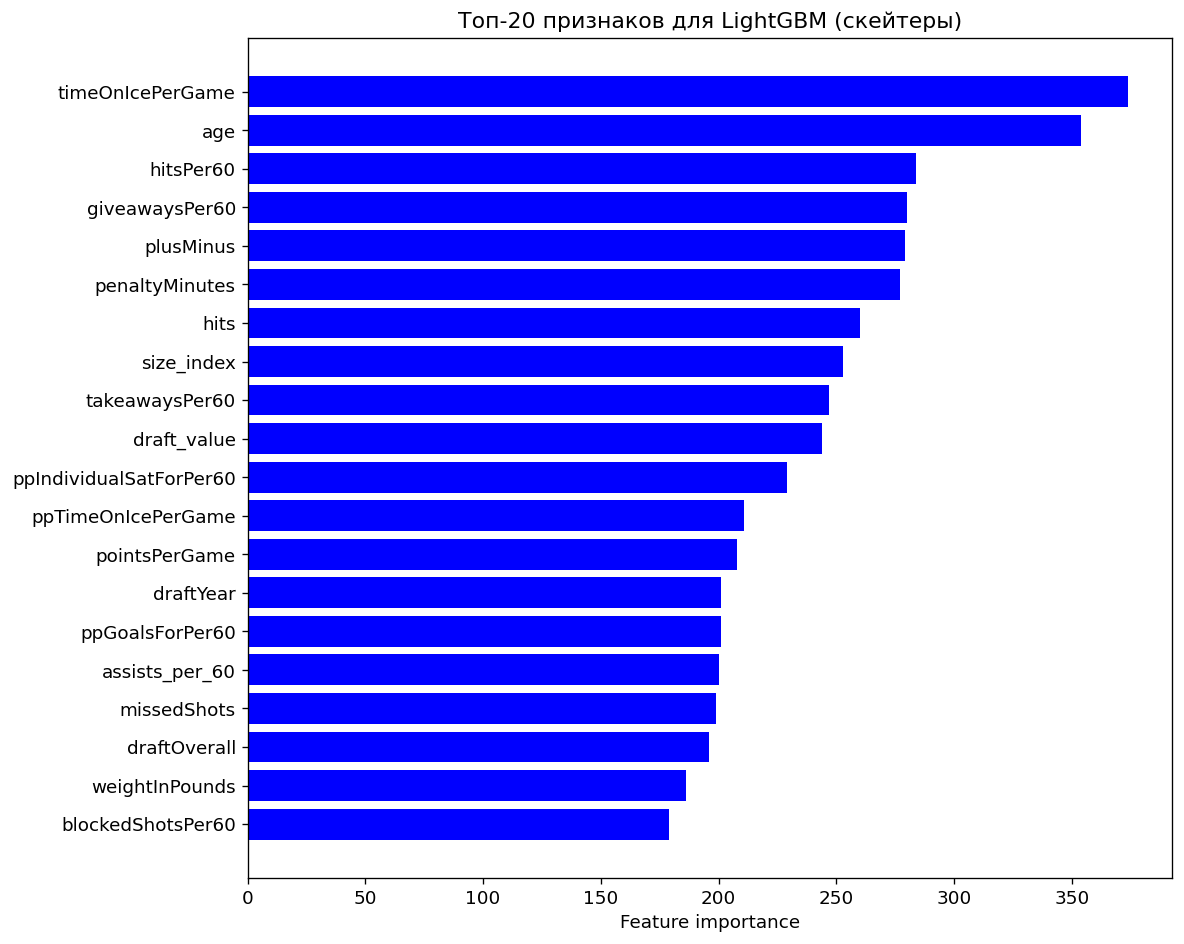

Топ-20 признаков:
timeOnIcePerGame           374
age                        354
hitsPer60                  284
giveawaysPer60             280
plusMinus                  279
penaltyMinutes             277
hits                       260
size_index                 253
takeawaysPer60             247
draft_value                244
ppIndividualSatForPer60    229
ppTimeOnIcePerGame         211
pointsPerGame              208
draftYear                  201
ppGoalsForPer60            201
assists_per_60             200
missedShots                199
draftOverall               196
weightInPounds             186
blockedShotsPer60          179


In [14]:
lgbm_pipeline = load_model("skaters_lightgbm")
lgbm_model = lgbm_pipeline.named_steps["model"]

importance = pd.Series(
    lgbm_model.feature_importances_,
    index=feature_cols_sk
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
top20 = importance.head(20)
ax.barh(top20.index[::-1], top20.values[::-1], color="blue")
ax.set_xlabel("Feature importance")
ax.set_title("Топ-20 признаков для LightGBM (скейтеры)")
plt.tight_layout()
plt.savefig(root / "report/images/feature_importance_lgbm.png", bbox_inches="tight")
plt.show()

print("Топ-20 признаков:")
print(importance.head(20).round(1).to_string())

Топ признаков частично совпадает с корреляционным анализом из EDA, но есть
неожиданные результаты:

**Ожидаемое:**
- `timeOnIcePerGame` лидер как и в корреляциях
- `ppTimeOnIcePerGame` важна роль в большинстве
- `pointsPerGame`, `assists_per_60` т.е. результативность важна

**Неожиданное:**
- `age` второй по важности, хотя корреляция была лишь 0.335.
  Дерево улавливает нелинейность которую корреляция Пирсона не видит
- `hitsPer60`, `giveawaysPer60`, `plusMinus`,
  `penaltyMinutes` поведенческие метрики в топе.
  Низкая линейная корреляция с таргетом не означает что признак бесполезен и
  деревья используют их в комбинации с другими
- `size_index` физические данные оказались важнее чем казалось
- `draft_value` и `draftYear` ценность на драфте важна
  для деревьев: GM платят больше игрокам с высоким драфт-статусом

**Вывод:** линейная корреляция недооценивает важность нелинейных и
взаимодействующих признаков. Деревья используют признаки иначе чем линейные модели.

## 7. Вратари

In [15]:
train_go, val_go, test_go = load_splits("goalies")
feature_cols_go = get_feature_cols(train_go)

x_train_go = train_go[feature_cols_go]
y_train_go = train_go[target_col]
x_val_go = val_go[feature_cols_go]
y_val_go = val_go[target_col]

print(f"Вратари: признаков: {len(feature_cols_go)}")
print(f"Train: {len(train_go)}, Val: {len(val_go)}, Test: {len(test_go)}")

results_go = []
run_baseline(x_train_go, y_train_go, x_val_go, y_val_go,
             results_go, prefix="goalies")
run_models(x_train_go, y_train_go, x_val_go, y_val_go,
           results_go, prefix="goalies")
run_dim_reduction(x_train_go, y_train_go, x_val_go, y_val_go,
                  results_go, prefix="goalies")

print()
print(format_results(results_go).to_string(index=False))

Вратари: признаков: 34
Train: 175, Val: 60, Test: 51

             label    MAE   RMSE    R²  MAPE
   baseline_linear 1.748M 2.438M 0.188 53.3%
             ridge 1.709M 2.339M 0.253 48.3%
     random_forest 1.483M 2.001M 0.453 43.7%
           xgboost 1.487M 1.974M 0.468 45.0%
          lightgbm 1.613M 2.160M 0.362 48.1%
lgbm_select_17feat 1.669M 2.231M 0.320 51.4%
  pca_16comp_ridge 1.744M 2.356M 0.242 46.8%


### Результаты моделей для вратарей (на val)

Качество заметно хуже чем у скейтеров: лучший R2 0.468 против 0.693.
Причины:
- Маленькая выборка: 175 строк в train это недостаточно для сложных моделей
- Зарплата вратаря определяется репутацией и историей контрактов,
  а не только статистикой одного сезона (Пример тому Carey Price: 1 победа, но зарплата 10.5M)
- LightGBM переобучается на маленькой выборке и уступает XGBoost и RF

Интересно: Random Forest лучше по MAE, XGBoost лучше по R2.
Приоритет скорее MAE, поэтому лучшей моделью пока что для вратарей считаем **Random Forest**.

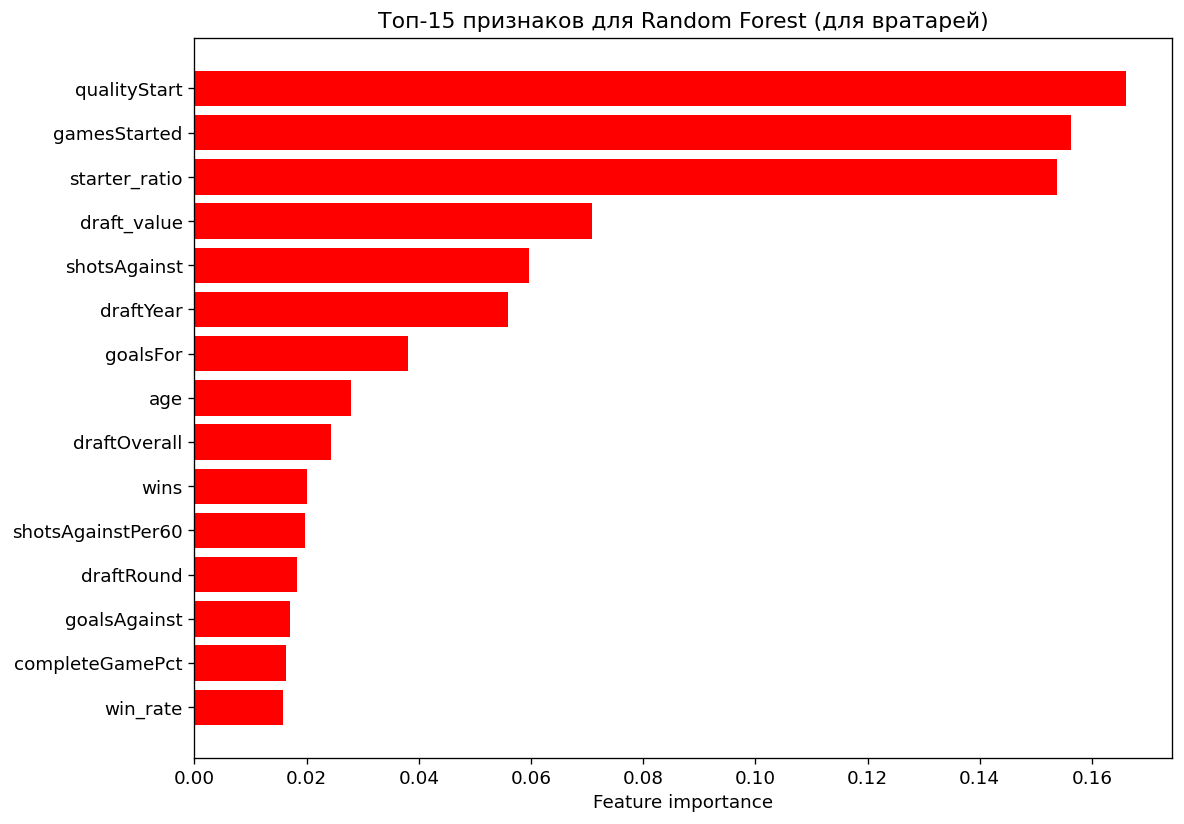

Топ-15 признаков вратарей:
qualityStart         0.1661
gamesStarted         0.1563
starter_ratio        0.1539
draft_value          0.0708
shotsAgainst         0.0597
draftYear            0.0559
goalsFor             0.0380
age                  0.0279
draftOverall         0.0244
wins                 0.0201
shotsAgainstPer60    0.0197
draftRound           0.0183
goalsAgainst         0.0170
completeGamePct      0.0163
win_rate             0.0158


In [16]:
rf_go_pipeline = load_model("goalies_random_forest")
rf_go_model = rf_go_pipeline.named_steps["model"]

importance_go = pd.Series(
    rf_go_model.feature_importances_,
    index=feature_cols_go
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
top15_go = importance_go.head(15)
ax.barh(top15_go.index[::-1], top15_go.values[::-1], color="red")
ax.set_xlabel("Feature importance")
ax.set_title("Топ-15 признаков для Random Forest (для вратарей)")
plt.tight_layout()
plt.savefig(root / "report/images/feature_importance_rf_goalies.png", bbox_inches="tight")
plt.show()

print("Топ-15 признаков вратарей:")
print(importance_go.head(15).round(4).to_string())

Топ признаков хорошо интерпретируется:

**Статус вратаря - главный фактор:**
- `qualityStart` - количество качественных стартов
- `gamesStarted` - количество стартов
- `starter_ratio` - доля стартов от игр

Все три меряют одно: является ли вратарь стартовым. Это подтверждает
вывод из EDA о том что платят за статус и надёжность, а не за savePct.

**Ценность на драфте:**
- `draft_value`, `draftYear`, `draftOverall`,
  `draftRound` суммарно примерно 17% важности.
  Высокий драфт-статус коррелирует с ожиданиями.

**Объём работы:**
- `shotsAgainst`, `goalsFor`, `wins` -
  абсолютные показатели зависят от количества игр.

**Качественные метрики почти отсутствуют:**
`savePct`, `gsaa_proxy`, `goalsAgainstAverage` не попали в топ-15 что
подтверждает что качество игры слабо влияет на зарплату вратаря.

**Итог по вратарям:** модель предсказывает зарплату прежде всего
по статусу и объёму игры. Для улучшения качества
на cp2 стоит добавить например статистику предыдущего сезона,
которая ближе к моменту подписания контракта. Ну или я найду больше данных по признакам и зарплатам чтобы больше джоинилось и никого не упускали.

## Итоги моделирования

### Финальные модели

| | Скейтеры | Вратари |
|---|---|---|
| Лучшая модель | LightGBM | Random Forest |
| MAE (val) | 1.095M | 1.483M |
| RMSE (val) | 1.602M | 2.001M |
| R² (val) | 0.693 | 0.453 |
| MAPE (val) | 34.3% | 43.7% |

### Что сделано на cp1
- Baseline (LinearRegression)
- 4 модели: Ridge, Random Forest, XGBoost, LightGBM
- 2 эксперимента с уменьшением размерности: SelectFromModel и PCA
- Feature importance для лучших моделей

### Что планируется на cp2
- Подбор гиперпараметров
- Ансамблевые модели
- SHAP для объяснения предсказаний
- Лаговые признаки для вратарей
- Финальная оценка на test
- И другие улучшения